In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap streamlit joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 87.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import joblib

In [ ]:
df = pd.read_csv(
    "/content/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

print(df.shape)

(7043, 21)


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


# **Understanding the target**

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


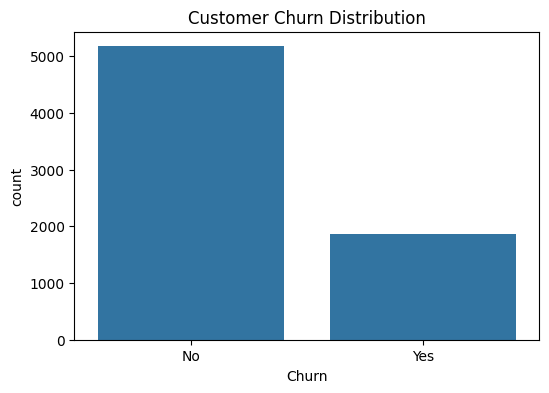

In [ ]:
print(df["Churn"].value_counts())
print(
    df["Churn"].value_counts(normalize=True) * 100
)
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.show()

# **Clean TotalCharges**

In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [ ]:
print(
    df["TotalCharges"].isnull().sum()
)

11


In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

# **Remove customer ID**

In [ ]:
df = df.drop(
    "customerID",
    axis=1
)

# **Convert Target**
yes--> 1
no--> 0

In [ ]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [ ]:
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


# **EDA**

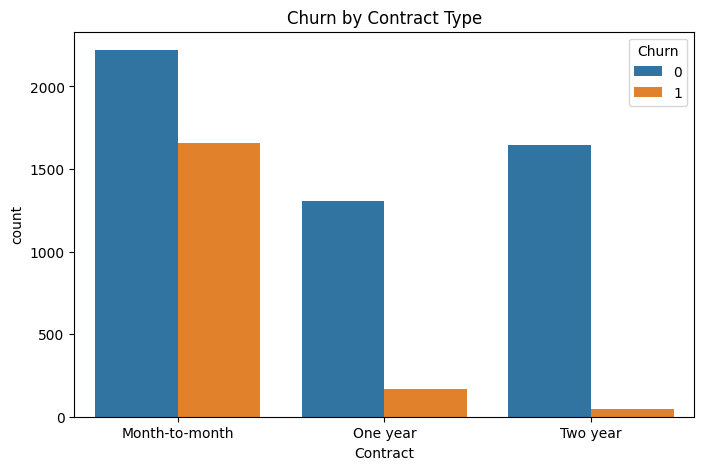

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title(
    "Churn by Contract Type"
)

plt.show()

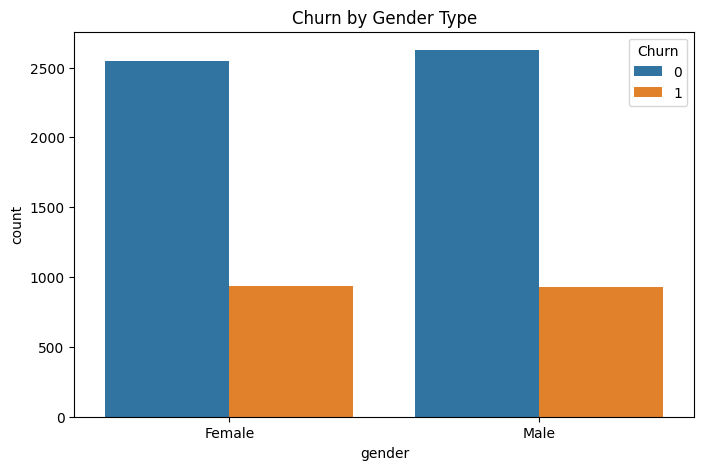

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title(
    "Churn by Gender Type"
)

plt.show()

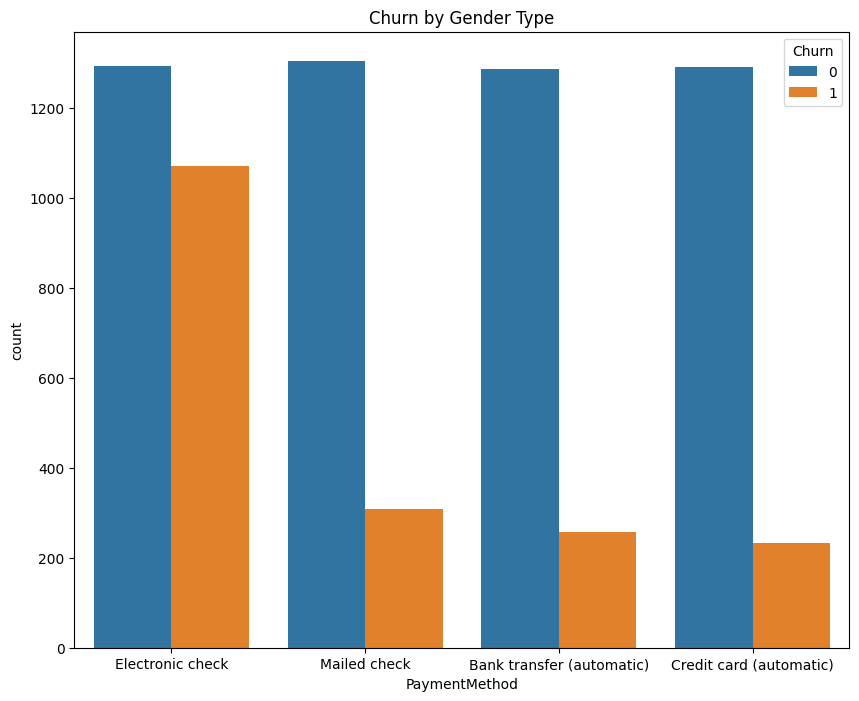

In [ ]:

plt.figure(figsize=(10, 8))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title(
    "Churn by Gender Type"
)

plt.show()

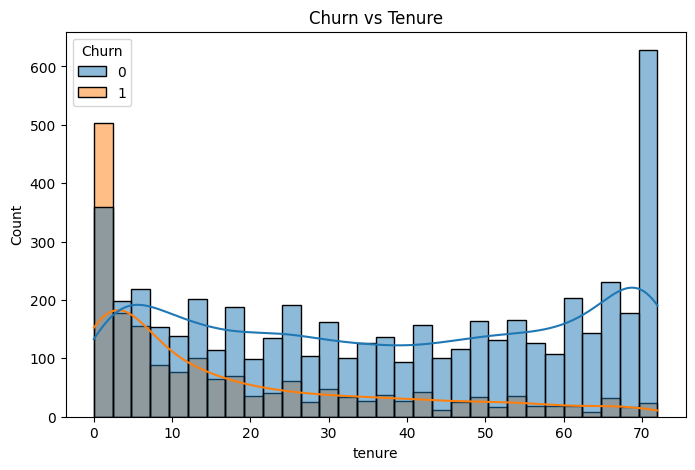

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Churn vs Tenure")
plt.show()

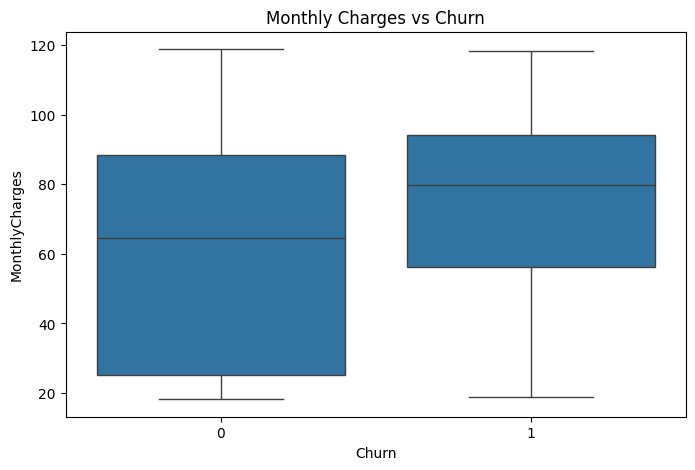

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title(
    "Monthly Charges vs Churn"
)

plt.show()

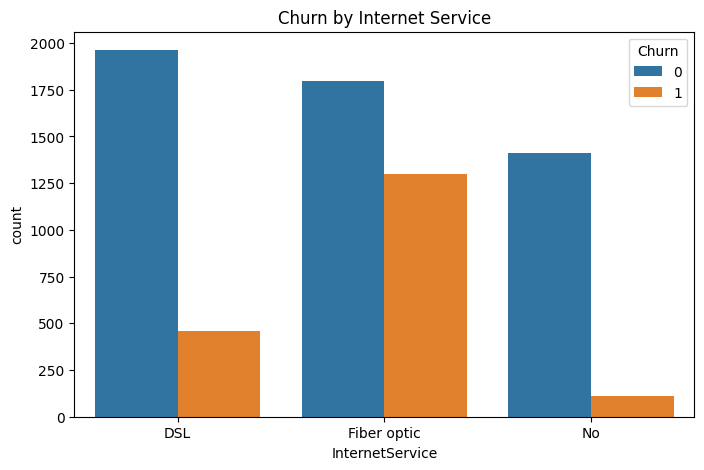

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title(
    "Churn by Internet Service"
)

plt.show()

In [ ]:
X = df.drop(
    "Churn",
    axis=1
)

y = df["Churn"]

In [ ]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical:")
print(categorical_cols)

print("\nNumerical:")
print(numerical_cols)

Categorical:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


# **Preprocessing**

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

# **Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (5634, 19)
Testing: (1409, 19)


# **Logistic Regression**

In [ ]:
#create pipeline
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)


#train
logistic_model.fit(
    X_train,
    y_train
)

#predict
lr_pred = logistic_model.predict(
    X_test
)

lr_prob = logistic_model.predict_proba(
    X_test
)[:, 1]

# **Random Forest**

In [ ]:
#create pipeline
rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

#train
rf_model.fit(
    X_train,
    y_train
)
#predict
rf_pred = rf_model.predict(
    X_test
)

rf_prob = rf_model.predict_proba(
    X_test
)[:, 1]

# **XGBoost**

In [ ]:
#create pipeline
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42
            )
        )
    ]
)

#train
xgb_model.fit(
    X_train,
    y_train
)
#predict
xgb_pred = xgb_model.predict(
    X_test
)

xgb_prob = xgb_model.predict_proba(
    X_test
)[:, 1]

# **Compare Models**

Create function

In [ ]:
def evaluate_model(
    name,
    y_true,
    predictions,
    probabilities
):

    return {
        "Model": name,
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions
        ),
        "Recall": recall_score(
            y_true,
            predictions
        ),
        "F1": f1_score(
            y_true,
            predictions
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        )
    }

Create Results

In [ ]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred,
        lr_prob
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred,
        xgb_prob
    )
)

Convert into dataframe

In [ ]:
results_df = pd.DataFrame(
    results
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841874
1,Random Forest,0.782115,0.617544,0.470588,0.534143,0.821664
2,XGBoost,0.798439,0.651007,0.518717,0.577381,0.841003


In [ ]:
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [ ]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.62      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [ ]:
print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



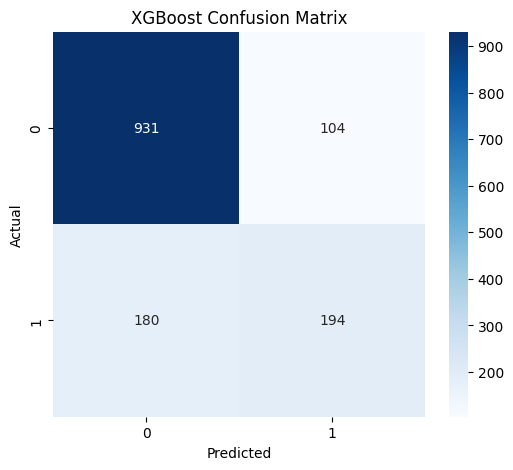

In [ ]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    "XGBoost Confusion Matrix"
)

plt.show()

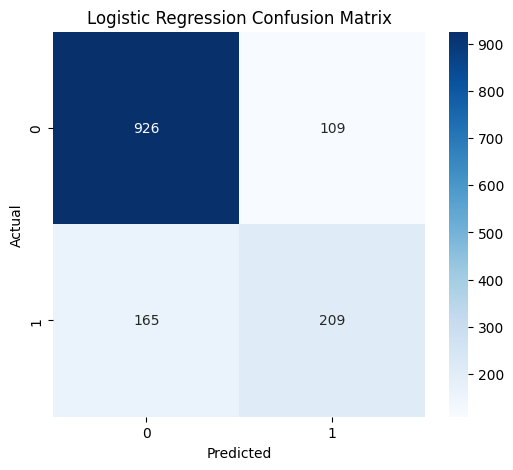

In [ ]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

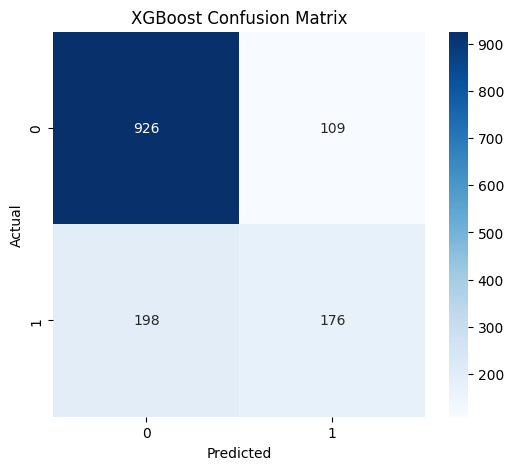

In [ ]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    "XGBoost Confusion Matrix"
)

plt.show()

In [ ]:
lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    lr_prob
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

xgb_fpr, xgb_tpr, _ = roc_curve(
    y_test,
    xgb_prob
)

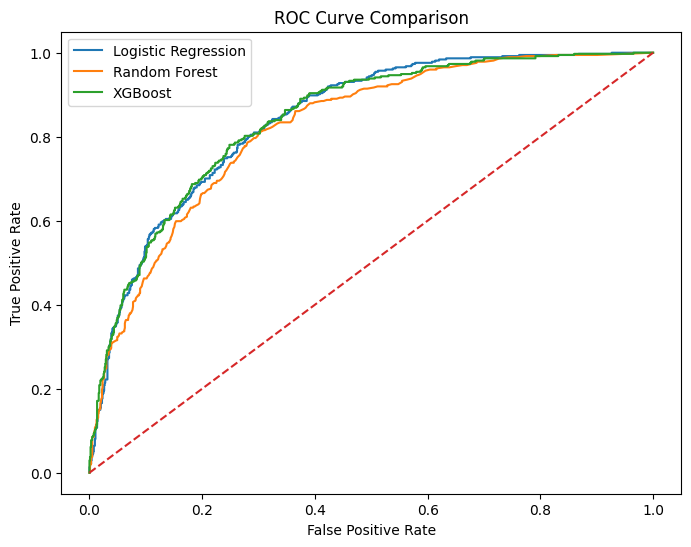

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label="Logistic Regression"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison"
)

plt.legend()

plt.show()

In [ ]:
import os

# Create the 'models' directory if it doesn't exist
os.makedirs('models', exist_ok=True)

joblib.dump(
    logistic_model,
    "models/churn_model.pkl"
)

['models/churn_model.pkl']

In [ ]:
def predict_churn(customer_data):

    probability = logistic_model.predict_proba(
        customer_data
    )[0][1]

    prediction = (
        "Yes"
        if probability >= 0.5
        else "No"
    )

    return prediction, probability

In [ ]:
customer = pd.DataFrame({
    "gender": ["Female"],
    "SeniorCitizen": [0],
    "Partner": ["No"],
    "Dependents": ["No"],
    "tenure": [2],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["No"],
    "StreamingMovies": ["No"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": [
        "Electronic check"
    ],
    "MonthlyCharges": [80.0],
    "TotalCharges": [160.0]
})

In [ ]:
prediction, probability = predict_churn(
    customer
)

print("Churn:", prediction)
print(
    "Probability:",
    f"{probability * 100:.2f}%"
)

Churn: Yes
Probability: 65.15%


# **Add SHAP explainability**

In [ ]:
!pip install shap
import shap

In [ ]:
preprocessor_fitted = logistic_model.named_steps[
    "preprocessor"
]

logistic_classifier = logistic_model.named_steps[
    "classifier"
]

In [ ]:
X_test_transformed = (
    preprocessor_fitted.transform(X_test)
)

In [ ]:
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

In [ ]:
explainer = shap.LinearExplainer(
    logistic_classifier,
    X_test_transformed
)

In [ ]:
shap_values = explainer.shap_values(
    X_test_transformed
)

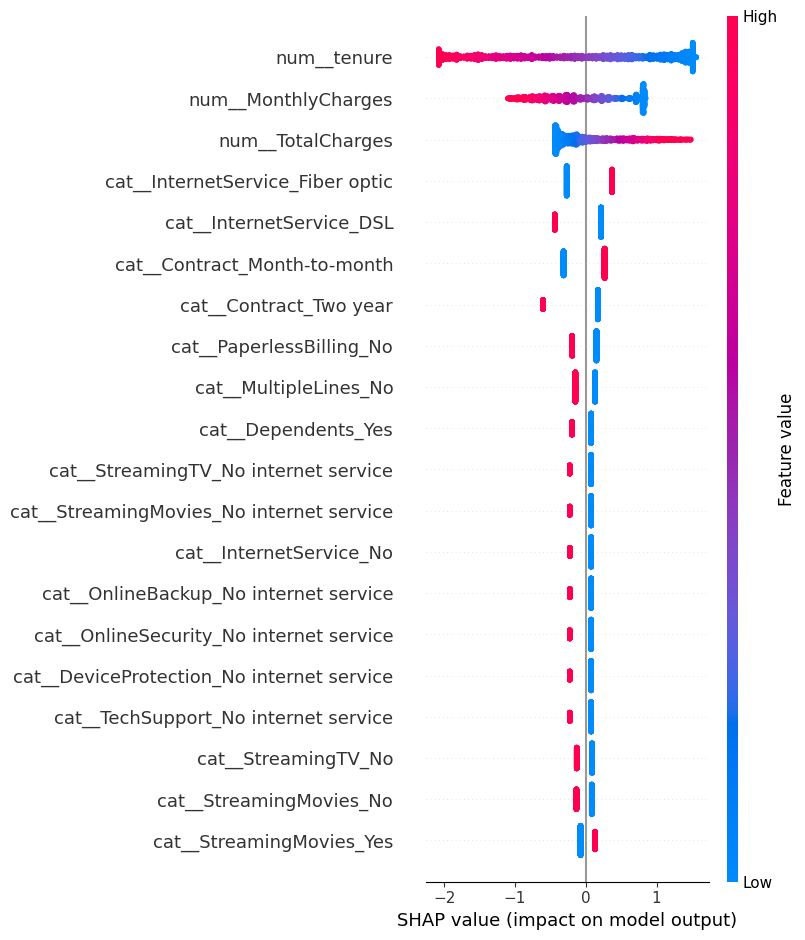

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)